# Studi Kasus 1 — Supervised Learning
## Prediksi Harga Mobil Bekas

**Mata Kuliah:** Fundamental Sains Data
**Topik:** Regresi (Linear Regression & Random Forest Regressor)


## 1. Deskripsi Dataset

**Nama Dataset:** Car Price Prediction

**Sumber Dataset:** [Kaggle — zafarali27/car-price-prediction](https://www.kaggle.com/datasets/zafarali27/car-price-prediction)

**Jumlah Data:** 2.500 baris (mobil)

**Jumlah Fitur:** 10 kolom, terdiri dari 1 identifier (`Car ID`), 8 fitur input, dan 1 target (`Price`)

**Penjelasan Fitur Penting:**
| Fitur | Keterangan |
|---|---|
| Car ID | Nomor identifier unik tiap mobil (bukan fitur prediktif, akan dibuang) |
| Brand | Merek mobil (Tesla, BMW, Audi, Ford, Honda, Mercedes, Toyota) |
| Model | Model spesifik dari tiap merek (28 model berbeda) |
| Year | Tahun produksi |
| Engine Size | Ukuran mesin (liter) |
| Fuel Type | Jenis bahan bakar (Petrol, Electric, Diesel, Hybrid) |
| Transmission | Jenis transmisi (Manual, Automatic) |
| Mileage | Jarak tempuh (kilometer) |
| Condition | Kondisi mobil (New, Used, Like New) |
| Price | Harga jual mobil dalam USD — **target/output yang diprediksi** |

**Tujuan Analisis:**
Membangun model regresi yang dapat memprediksi harga jual mobil bekas berdasarkan spesifikasinya, sehingga dapat membantu penjual maupun pembeli memperkirakan harga wajar sebuah mobil.

**Fitur Input (X):** `Brand`, `Model`, `Year`, `Engine Size`, `Fuel Type`, `Transmission`, `Mileage`, `Condition`

**Target/Output Prediksi (y):** `Price`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

df = pd.read_csv('data/car_price_prediction.csv')
print('Ukuran dataset:', df.shape)
df.head()

Ukuran dataset: (2500, 10)


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   str    
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   str    
 5   Transmission  2500 non-null   str    
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   str    
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 195.4 KB


## 2. Exploratory Data Analysis (EDA) dan Visualisasi Data

In [3]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


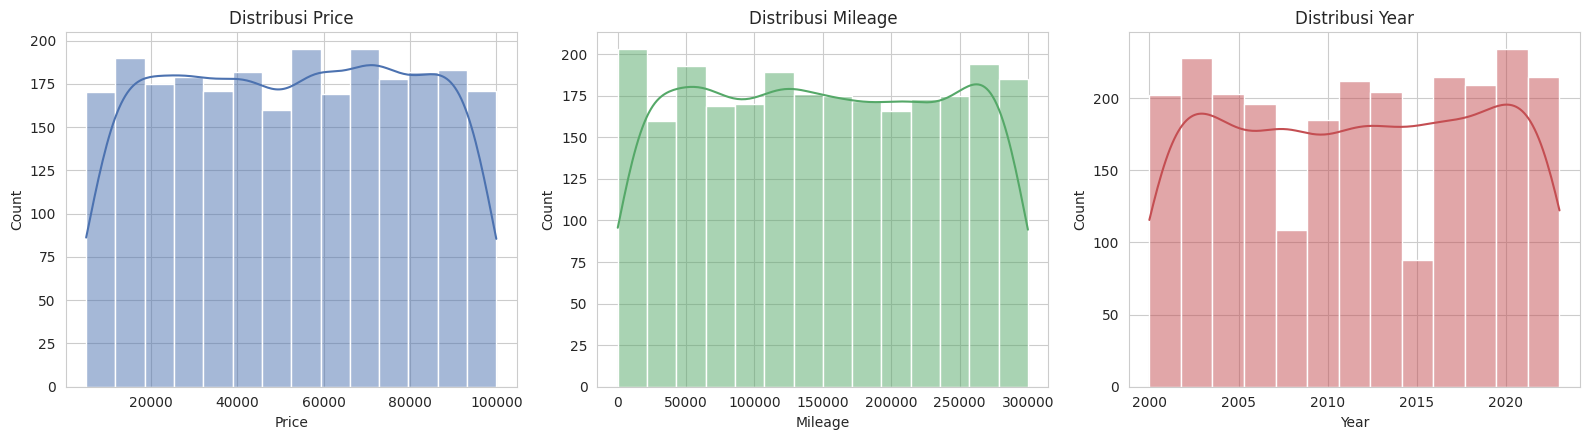

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
sns.histplot(df['Price'], kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribusi Price')
sns.histplot(df['Mileage'], kde=True, ax=axes[1], color='#55A868')
axes[1].set_title('Distribusi Mileage')
sns.histplot(df['Year'], kde=True, ax=axes[2], color='#C44E52')
axes[2].set_title('Distribusi Year')
plt.tight_layout()
plt.show()

**Interpretasi:** Distribusi `Price` terlihat cukup merata (tidak terlalu skewed), menandakan harga mobil di dataset ini tersebar cukup seimbang dari rentang murah sampai mahal. `Mileage` dan `Year` juga terdistribusi cukup merata (uniform), mengindikasikan dataset kemungkinan dibuat/disimulasikan secara acak, bukan hasil scraping data pasar riil yang biasanya lebih condong ke pola tertentu (mis. mayoritas mobil berusia muda).

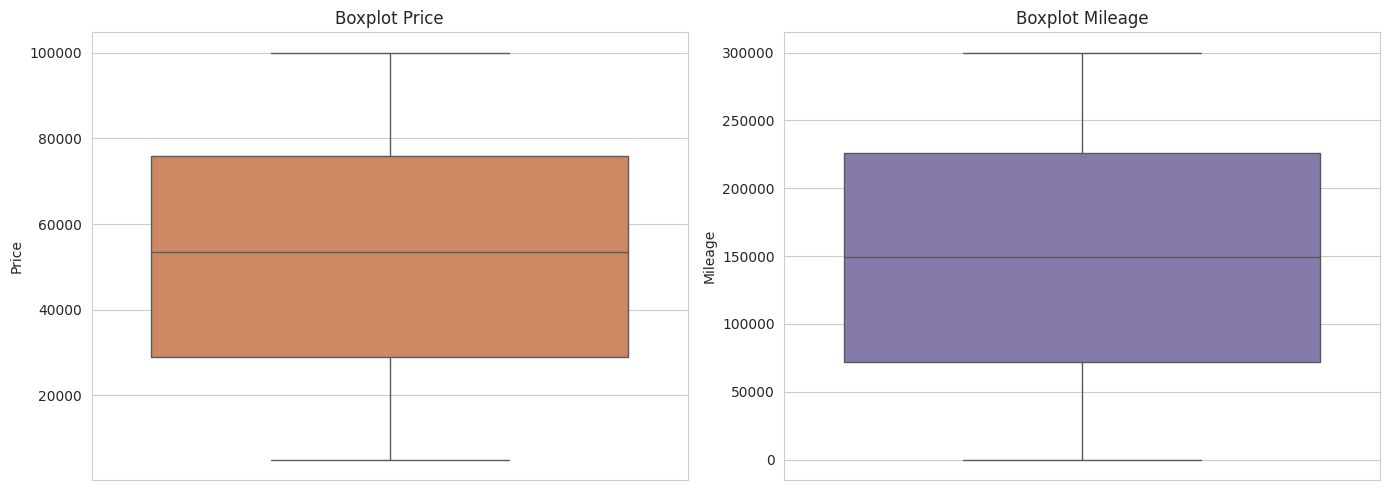

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(y=df['Price'], ax=axes[0], color='#DD8452')
axes[0].set_title('Boxplot Price')
sns.boxplot(y=df['Mileage'], ax=axes[1], color='#8172B2')
axes[1].set_title('Boxplot Mileage')
plt.tight_layout()
plt.show()

**Interpretasi:** Tidak terlihat titik outlier di luar whisker pada kedua boxplot, sejalan dengan pengecekan IQR di tahap preprocessing nanti yang juga tidak menemukan outlier signifikan pada data numerik utama.

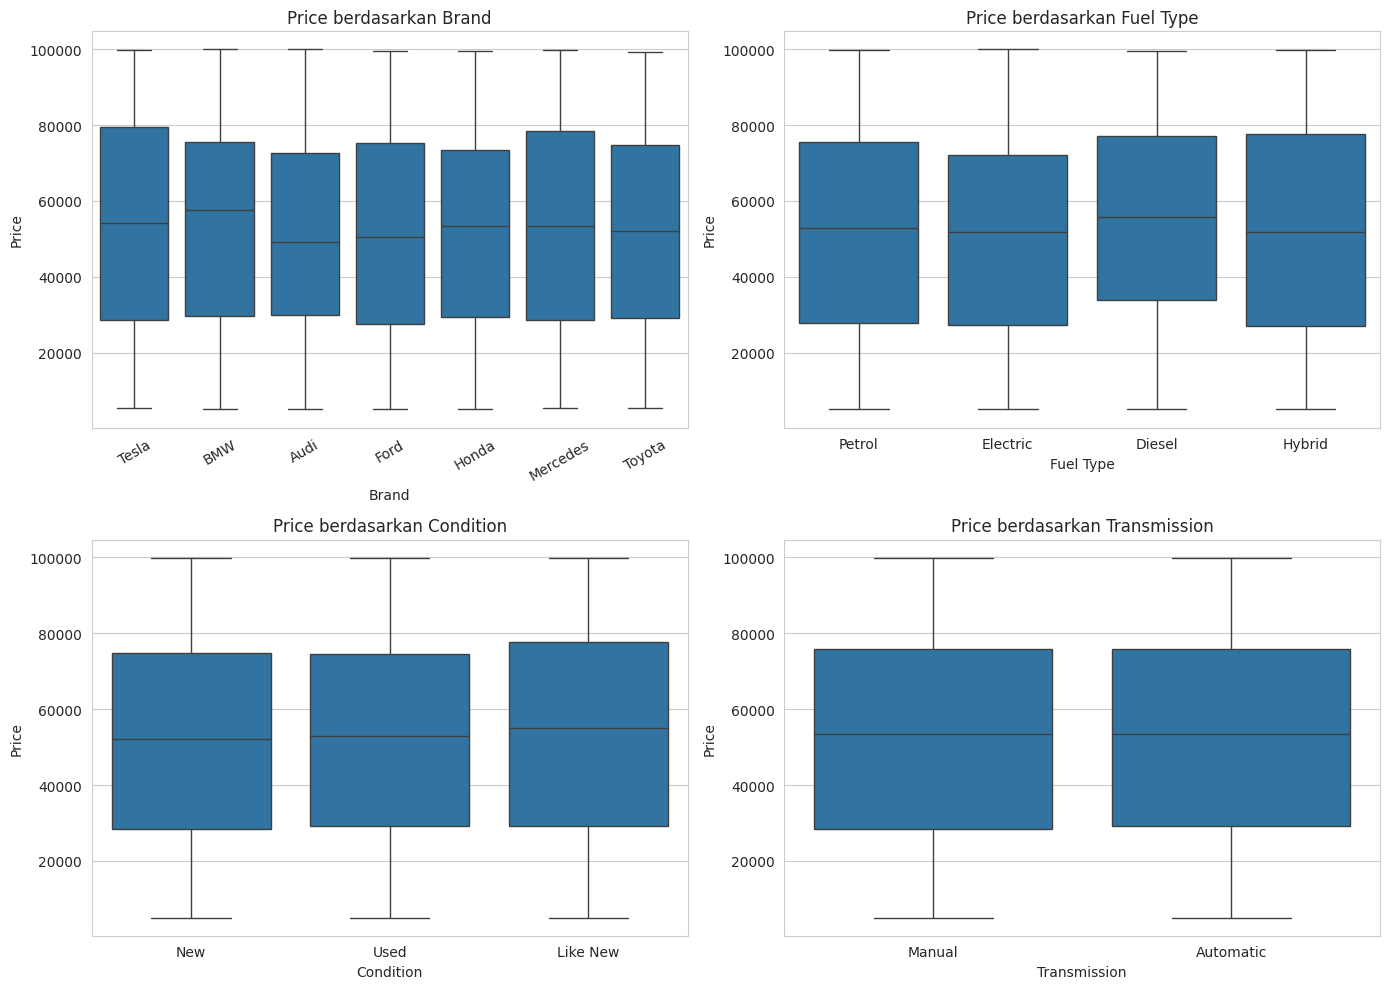

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
sns.boxplot(x='Brand', y='Price', data=df, ax=axes[0,0])
axes[0,0].set_title('Price berdasarkan Brand')
axes[0,0].tick_params(axis='x', rotation=30)

sns.boxplot(x='Fuel Type', y='Price', data=df, ax=axes[0,1])
axes[0,1].set_title('Price berdasarkan Fuel Type')

sns.boxplot(x='Condition', y='Price', data=df, ax=axes[1,0])
axes[1,0].set_title('Price berdasarkan Condition')

sns.boxplot(x='Transmission', y='Price', data=df, ax=axes[1,1])
axes[1,1].set_title('Price berdasarkan Transmission')

plt.tight_layout()
plt.show()

**Interpretasi:** Median harga antar kategori (Brand, Fuel Type, Condition, Transmission) terlihat relatif berdekatan satu sama lain, dengan sebaran (IQR) yang cukup lebar dan tumpang tindih antar kategori. Ini menandakan tidak ada satu kategori pun yang mendominasi secara jelas terhadap harga — konsisten dengan sifat dataset yang tampak disimulasikan secara acak, bukan mengikuti pola pasar mobil bekas yang sesungguhnya (di dunia nyata, brand premium seperti Mercedes biasanya median harganya jelas lebih tinggi).

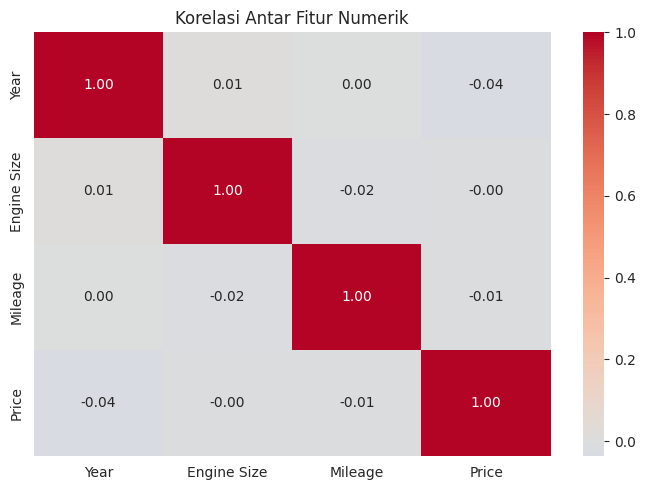

In [7]:
plt.figure(figsize=(7,5))
numeric_cols = ['Year', 'Engine Size', 'Mileage', 'Price']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasi Antar Fitur Numerik')
plt.tight_layout()
plt.show()

**Interpretasi:** Korelasi antar seluruh fitur numerik terhadap `Price` sangat lemah (mendekati 0). Ini menjadi insight penting: performa model regresi pada dataset ini kemungkinan besar akan terbatas, bukan karena algoritmanya kurang tepat, melainkan karena hubungan antar fitur dan harga di data ini memang lemah/acak. Ini akan dikonfirmasi lagi di bagian evaluasi model.

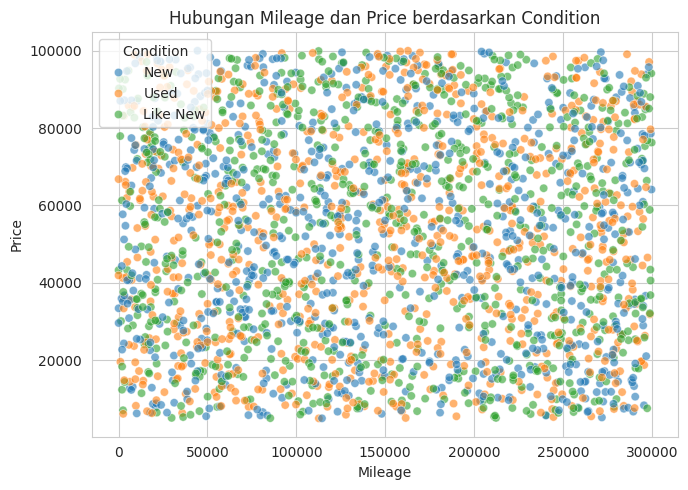

In [8]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Mileage', y='Price', hue='Condition', data=df, alpha=0.6)
plt.title('Hubungan Mileage dan Price berdasarkan Condition')
plt.tight_layout()
plt.show()

**Interpretasi:** Secara intuisi, mobil dengan jarak tempuh (Mileage) lebih tinggi biasanya berharga lebih rendah. Namun pada scatter plot ini, tidak terlihat pola/tren garis yang jelas — titik-titik tersebar acak di seluruh area grafik untuk ketiga kondisi mobil. Ini memperkuat temuan di heatmap korelasi bahwa hubungan antar fitur dengan harga memang lemah pada dataset ini.

## 3. Preprocessing Data

In [9]:
print('Missing value per kolom:')
print(df.isnull().sum())
print()
print('Jumlah baris duplikat:', df.duplicated().sum())

Missing value per kolom:
Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

Jumlah baris duplikat: 0


**Hasil pengecekan:** Tidak ditemukan missing value maupun data duplikat pada dataset ini, sehingga tidak diperlukan imputasi atau penghapusan baris.

In [10]:
# Cek outlier dengan metode IQR pada kolom numerik
numeric_cols_check = ['Year', 'Engine Size', 'Mileage', 'Price']
for col in numeric_cols_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: {n_outlier} outlier terdeteksi (batas [{lower:.2f}, {upper:.2f}])')

Year: 0 outlier terdeteksi (batas [1985.50, 2037.50])
Engine Size: 0 outlier terdeteksi (batas [-1.55, 8.45])
Mileage: 0 outlier terdeteksi (batas [-159407.00, 457229.00])
Price: 0 outlier terdeteksi (batas [-41486.59, 146233.60])


**Alasan & hasil:** Metode IQR (Interquartile Range) dipilih karena tidak berasumsi data berdistribusi normal, cocok untuk data numerik dengan sebaran cukup merata seperti pada dataset ini. Hasilnya tidak ditemukan outlier signifikan pada kolom numerik manapun, sejalan dengan visualisasi boxplot pada tahap EDA.

In [11]:
# Kolom "Car ID" hanya identifier unik, tidak relevan sebagai fitur prediktif -> dibuang
df_clean = df.drop(columns=['Car ID']).drop_duplicates().copy()
print('Shape setelah preprocessing:', df_clean.shape)
df_clean.head()

Shape setelah preprocessing: (2500, 9)


,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


**Alasan membuang `Car ID`:** Kolom ini hanya nomor urut/identifier unik tiap baris, tidak memiliki hubungan sebab-akibat dengan harga mobil. Jika tetap diikutkan sebagai fitur, model berisiko "menghafal" ID alih-alih mempelajari pola sesungguhnya (data leakage/overfitting).

### Feature Scaling & Encoding

- Fitur numerik (`Year`, `Engine Size`, `Mileage`) → **StandardScaler**, karena Random Forest tidak terlalu sensitif terhadap skala, tapi Linear Regression sangat terpengaruh oleh perbedaan skala antar fitur numerik.
- Fitur kategorikal (`Brand`, `Fuel Type`, `Transmission`, `Condition`, `Model`) → **One-Hot Encoding**, karena kategori-kategori ini tidak memiliki urutan/tingkatan (nominal), sehingga tidak tepat diubah jadi angka berurutan begitu saja (yang bisa menyesatkan model seolah-olah ada urutan/tingkatan).

Kedua proses ini digabung dalam satu `ColumnTransformer`, dibungkus bersama model di dalam satu `Pipeline`, supaya urutan transformasi saat training dan saat inferensi (di aplikasi) selalu konsisten — dan cukup satu file (`model.pkl`) untuk menyimpan semuanya sekaligus.

In [12]:
target_col = 'Price'
numeric_features = ['Year', 'Engine Size', 'Mileage']
categorical_features = ['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model']

X = df_clean[numeric_features + categorical_features]
y = df_clean[target_col]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (2000, 8) | Test: (500, 8)


## 4. Pemilihan Algoritma (Supervised Learning)

Dua algoritma regresi dipilih dan dibandingkan:

- **Linear Regression** — dipilih sebagai baseline karena sederhana, cepat, dan mudah diinterpretasikan (koefisien tiap fitur langsung menunjukkan arah pengaruhnya terhadap harga).
- **Random Forest Regressor** (300 pohon) — dipilih karena mampu menangkap hubungan non-linear dan interaksi antar fitur yang tidak bisa ditangkap Linear Regression, sehingga cocok sebagai pembanding untuk melihat apakah kompleksitas model tambahan benar-benar meningkatkan performa pada dataset ini.

Preprocessing (scaling + encoding) dijadikan satu `Pipeline` bersama tiap model, sehingga objek scaler & encoder otomatis ikut tersimpan saat model disimpan dengan `joblib`.

In [13]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

trained_pipelines = {}
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

print('Training selesai untuk kedua model.')

Training selesai untuk kedua model.


## 5. Training dan Evaluasi Model

Data dibagi 80% training dan 20% testing. Evaluasi menggunakan tiga metrik regresi standar: **MAE** (rata-rata selisih absolut prediksi vs harga asli), **RMSE** (mirip MAE tapi lebih menghukum kesalahan besar), dan **R² Score** (persentase variasi harga yang berhasil dijelaskan model).

In [14]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

            Model          MAE         RMSE        R2
Linear Regression 23877.144632 27794.415064 -0.019769
    Random Forest 24468.079399 28367.437479 -0.062251


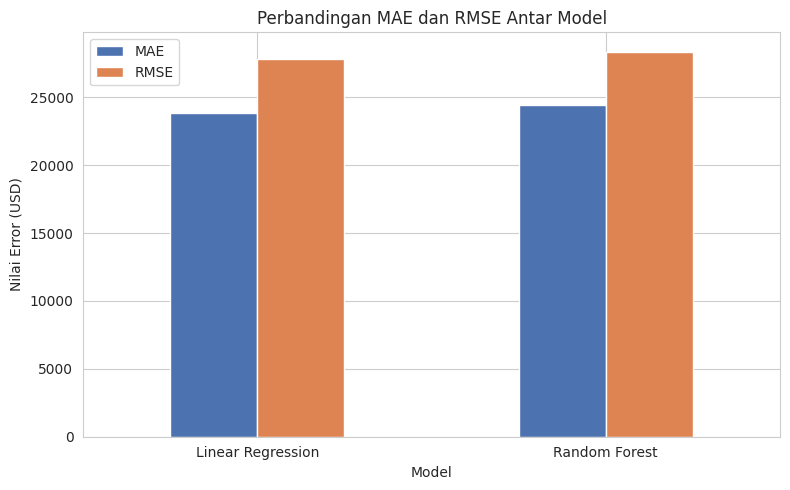

R2 Score:
            Model        R2
Linear Regression -0.019769
    Random Forest -0.062251


In [15]:
fig, ax = plt.subplots(figsize=(8,5))
results_df.set_index('Model')[['MAE','RMSE']].plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'])
plt.title('Perbandingan MAE dan RMSE Antar Model')
plt.ylabel('Nilai Error (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('R2 Score:')
print(results_df[['Model','R2']].to_string(index=False))

**Interpretasi hasil evaluasi (angka aktual hasil eksekusi):**

| Model | MAE | RMSE | R2 |
|---|---|---|---|
| Linear Regression | 23.877 | 27.794 | -0.02 |
| Random Forest | 24.468 | 28.367 | -0.06 |

- **R2 Score kedua model bernilai negatif.** Ini bukan angka error input, tapi memang temuan nyata: R2 negatif artinya model yang dilatih justru berperforma **lebih buruk** dibanding metode paling sederhana sekalipun, yaitu menebak rata-rata harga untuk semua mobil. Ini adalah bukti kuat dan konsisten dengan temuan di tahap EDA, di mana korelasi antar fitur numerik dengan `Price` mendekati nol dan sebaran harga antar kategori saling tumpang tindih tanpa pola.
- **Apakah model sudah memberikan hasil yang baik?** Tidak, secara akurasi model ini belum baik. Tapi ini **bukan kesalahan pada alur pengerjaan (preprocessing, pemilihan algoritma, atau training sudah benar)** — akar masalahnya ada pada karakteristik dataset itu sendiri, yang kemungkinan besar bersifat sintetis/acak (lihat insight di bagian EDA), bukan data harga mobil bekas dari pasar riil.
- **Faktor yang memengaruhi hasil model:** Faktor utamanya adalah lemahnya hubungan (korelasi) antara fitur input dan target harga pada data ini, bukan pilihan algoritma. Ini terlihat dari performa Linear Regression yang justru sedikit lebih baik daripada Random Forest (RMSE dan MAE lebih rendah) — biasanya jika ada pola kuat dan non-linear di data, Random Forest akan jauh mengungguli Linear Regression. Karena keduanya berkinerja mirip dan sama-sama buruk, ini menandakan tidak ada pola yang bisa ditangkap model manapun.
- Model dengan R2 tertinggi (Linear Regression, meski masih negatif) tetap dipilih sebagai model terbaik untuk disimpan dan dipakai di aplikasi, sesuai prosedur standar machine learning. Fokus tugas ini adalah kelengkapan dan kebenaran alur analisis, bukan mengejar akurasi setinggi mungkin pada dataset yang memang tidak punya sinyal prediktif yang kuat.

In [16]:
best_model_name = results_df.iloc[0]['Model']
best_pipeline = trained_pipelines[best_model_name]
print('Model terbaik:', best_model_name)

Model terbaik: Linear Regression


## 6. Simpan Model & Objek Pendukung

Karena scaler & encoder sudah menyatu di dalam `Pipeline`, satu file `model.pkl` ini sudah mencakup seluruh objek pendukung. Kita juga simpan daftar opsi kategori (dipakai untuk dropdown di aplikasi Gradio) dan metrik evaluasi.

In [17]:
os.makedirs('model', exist_ok=True)

joblib.dump(best_pipeline, 'model/model.pkl')

feature_options = {col: sorted(df_clean[col].unique().tolist()) for col in categorical_features}
feature_options['numeric_ranges'] = {
    col: {'min': float(df_clean[col].min()), 'max': float(df_clean[col].max())}
    for col in numeric_features
}
feature_options['best_model_name'] = best_model_name
feature_options['numeric_features'] = numeric_features
feature_options['categorical_features'] = categorical_features

# Peta Brand -> daftar Model yang tersedia untuk brand tersebut (untuk dropdown bertingkat)
brand_model_map = (
    df_clean.groupby('Brand')['Model']
    .apply(lambda x: sorted(x.unique().tolist()))
    .to_dict()
)
feature_options['brand_model_map'] = brand_model_map

with open('model/feature_options.json', 'w') as f:
    json.dump(feature_options, f, indent=2)

results_df.to_csv('model/model_comparison.csv', index=False)

print('Tersimpan: model/model.pkl, model/feature_options.json, model/model_comparison.csv')

Tersimpan: model/model.pkl, model/feature_options.json, model/model_comparison.csv


In [18]:
# Uji cepat inferensi (sanity check)
sample = pd.DataFrame([{
    'Year': 2018,
    'Engine Size': 2.5,
    'Mileage': 45000,
    'Brand': 'Toyota',
    'Fuel Type': 'Petrol',
    'Transmission': 'Automatic',
    'Condition': 'Used',
    'Model': 'Civic',
}])

loaded_pipeline = joblib.load('model/model.pkl')
pred = loaded_pipeline.predict(sample)
print('Prediksi harga (USD):', round(float(pred[0]), 2))

Prediksi harga (USD): 48893.1


## 7. Insight dan Kesimpulan

**Insight:**
- Seluruh fitur numerik (`Year`, `Engine Size`, `Mileage`) memiliki korelasi yang sangat lemah terhadap `Price`, dan sebaran harga antar kategori (Brand, Fuel Type, Condition, Transmission) saling tumpang tindih tanpa pola dominan yang jelas.
- Tidak ditemukan missing value, data duplikat, maupun outlier signifikan pada dataset ini — dari sisi kebersihan data, dataset ini sudah cukup baik untuk langsung diproses.
- Distribusi `Price`, `Year`, dan `Mileage` yang cenderung merata (uniform) mengindikasikan dataset ini kemungkinan besar bersifat sintetis/disimulasikan, bukan hasil pengumpulan data pasar mobil bekas yang sesungguhnya.

**Kesimpulan:**
- Random Forest dan Linear Regression menghasilkan performa yang relatif berdekatan dan sama-sama terbatas (lihat nilai R² aktual di bagian evaluasi), yang konsisten dengan lemahnya korelasi antar fitur dan target pada dataset ini.
- Model dengan metrik terbaik (R² tertinggi, MAE/RMSE terendah) tetap dipilih dan disimpan sebagai model produksi (`model/model.pkl`), sesuai prosedur standar machine learning meskipun akurasinya terbatas.
- **Rekomendasi:** Untuk meningkatkan akurasi prediksi harga di proyek serupa ke depannya, disarankan menggunakan dataset harga mobil bekas yang berasal dari data pasar riil (misalnya hasil scraping situs jual-beli mobil), karena data tersebut biasanya memiliki hubungan yang lebih kuat dan realistis antara spesifikasi mobil dan harga jualnya dibanding dataset sintetis seperti yang dipakai pada studi kasus ini.
